### Demoblatt
--- 



# `GaussianNB - Naive Bayes Classification`


The [Naive Bayes Classifier](http://dataaspirant.com/2017/02/06/naive-bayes-classifier-machine-learning/) technique is based on the so-called Bayesian theorem and is particularly suited when the dimensionality of the inputs is high. Despite its simplicity, Naive Bayes can often outperform more sophisticated classification methods.

### Bayes' Theorem

The algorithm is based on the famous [___Bayes theorem___](https://en.wikipedia.org/wiki/Bayes%27_theorem) named after Rev. Thomas Bayes. It works on conditional probability. [Conditional probability](https://en.wikipedia.org/wiki/Conditional_probability) is the probability that something will happen, given that something else has already occurred. Using the conditional probability, we can calculate the probability of an event using its prior knowledge.

Bayes' theorem is stated mathematically as the following equation:

$${\displaystyle P(A\mid B)={\frac {P(B\mid A)\,P(A)}{P(B)}},}$$
where $A$ and $B$ are events and $P(B)\neq{0}$.

$P(A\mid B)$ is a [conditional probability](https://en.wikipedia.org/wiki/Conditional_probability): the likelihood of event $A$ occurring given that $B$ is true.

$P(B\mid A)$ is also a conditional probability: the likelihood of event $B$ occurring given that $A$ is true.

$P(A)$ and $P(B)$ are the probabilities of observing $A$ and $B$ independently of each other; this is known as the [marginal probability](https://en.wikipedia.org/wiki/Marginal_probability).

### What's _Naive_ in Naive Bayes and why is it a super fast algorithm?

It is called naive Bayes or idiot Bayes because the calculation of the probabilities for each hypothesis are simplified to make their calculation tractable. Rather than attempting to calculate the values of each attribute value, they are assumed to be conditionally independent given the target value.

This is a very strong assumption that is most unlikely in real data, i.e. that the attributes do not interact. Nevertheless, the approach performs surprisingly well on data where this assumption does not hold.

Training is fast because only the probability of each class and the probability of each class given different input values need to be calculated. **No coefficients need to be fitted by optimization procedures.**

The class probabilities are simply the frequency of instances that belong to each class divided by the total number of instances. The conditional probabilities are the frequency of each attribute value for a given class value divided by the frequency of instances with that class value.

### Data analyzed in this notebook

In this notebook, we will show how to use Python scikit-learn's Naive Bayes method to classify origin of wine based on physio-chemical analysis data. These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines.

Details can be [**found here**](http://archive.ics.uci.edu/ml/datasets/Wine).

Given a class variable $y$ and a dependent feature vector $x_1$ through $x_n$, Bayes’ theorem states the following relationship:

$$P(y \mid x_1, \dots, x_n) = \frac{P(y) P(x_1, \dots x_n \mid y)} {P(x_1, \dots, x_n)}$$
Using the naive independence assumption that
$$P(x_i | y, x_1, \dots, x_{i-1}, x_{i+1}, \dots, x_n) = P(x_i | y),$$
for all $i$, this relationship is simplified to
$$P(y \mid x_1, \dots, x_n) = \frac{P(y) \prod_{i=1}^{n} P(x_i \mid y)} {P(x_1, \dots, x_n)}$$

Since $P(x_1, \dots, x_n)$ is constant given the input, we can use the following classification rule:
$$P(y \mid x_1, \dots, x_n) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$
$$\Downarrow$$ 
$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i \mid y),$$

and we can use [**Maximum A Posteriori**](https://en.wikipedia.org/wiki/Maximum_a_posteriori_estimation) (MAP) estimation to estimate $P(y)$ and $P(x_i \mid y)$; the former is then the relative frequency of class $y$ in the training set.

***GaussianNB ()*** implements the Gaussian Naive Bayes algorithm for classification. **The likelihood of the features is assumed to be Gaussian**:

$$ P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma^2_y}} \exp(-\frac{(x_i - \mu_y)^2}{2\sigma^2_y}) $$

The parameters $\sigma_y$ and $\mu_y$ are estimated using maximum likelihood.

<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Vorhersage der Weinqualität auf Grund von ``od280/od315_of_diluted_wines`` und ``flavanoids``.

---



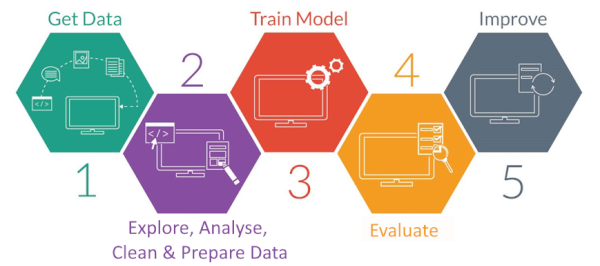

---
# 🟨 ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

Darstellen wie die Klassen verteilt sind

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
plt.figure(figsize=(6, 4))

#------------------------------------------------------------
# Trainingsdaten ausgeben
sns.scatterplot(data=dfWine, x='od280/od315_of_diluted_wines', y='flavanoids', hue='class', palette='Set1')

---
# 🟨 ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['od280/od315_of_diluted_wines', 'flavanoids']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Features Skalieren

In [ ]:
#-------------------------------------------------------------
# Führe später die Übung ein weiteres mal mit skalierten Daten durch
# ---> Dein Code 



### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# 🟨 ``Schritt 3:`` Modell erstellen und trainieren


### Modell erstellen und trainieren



In [ ]:
from sklearn.naive_bayes import GaussianNB

#------------------------------------------------------------
# Modell erstellen und trainieren
model = GaussianNB()
model.fit(train_x, train_y) 

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

Visueller Vergleich der tatsächlichen und der vorhergesagten Werte

In [ ]:
# Vergleiche die ersten 5 Werte der Testdaten mit den vorhergesagten Werten
print("Testdaten: ")
print ("Tatsächlich: ", test_y [0:5])
print ("Vorhersagen: ", pred_y [0:5])

---
# 🟨 ``Schritt 4:`` Evaluieren


## 🔷 Genauigkeit des Modells

Die Genauigkeit der Vorhersage kann mittels eines **``accuracy_score``** ermittelt werden.

In [ ]:
# Prüfen der Genauigkeit des Models
from sklearn import metrics

print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit des Modells sagen?<br>
 Begründe deine Antwort!**<br>  
 
86% der Trainingsdaten und 81% der Testdaten werden korrekt vorhergesagt. 

Das Modell scheint sehr ausgewogen zu sein und gute Ergebnisse zu liefern. Es sollte jedoch noch optimiert werden.

---
</div>

## 🔷 Visualisieren der Entscheidungsgrenzen


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#------------------------------------------------------------
# Entscheidungsgrenzen des Modells visualisieren
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator( 
            model, train_x, xlabel='diluted',ylabel='flavanoids', 
            alpha=0.5, eps=0.5, ax=axs[0], cmap = 'brg')

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, xlabel='diluted',ylabel='flavanoids', 
            alpha=0.5, eps=0.5, ax=axs[1], cmap = 'brg')

#------------------------------------------------------------
# Tatsächliche Werte anzeigen
sns.scatterplot(x=train_x[:,0], y=train_x[:,1], hue=train_y, palette= ['b','r','g'],  ax=axs[0], hue_order=model.classes_)
sns.scatterplot(x=test_x [:,0], y=test_x [:,1], hue=test_y,  palette= ['b','r','g'],  ax=axs[1], hue_order=model.classes_)

plt.show()

---

# 🟨 Praxistest



In [ ]:
# Testdaten generieren
diluted = 3.5
flavanoids  = 2.6
test_data = [[diluted, flavanoids]]

# Vorhersage erstellen
wclass = model.predict(test_data)

# Species ausgeben
print("Vorhersage der Klasse: ", wclass[0])

Nun stellt sich noch die Frage, wie hoch ist die Wahrscheinlichkeit das die Vorhersage richtig ist.  
Dazu kann mit ``predict_proba``, die Wahrscheinlichkeit für jede einzelne Kategorie ermittelt werden.

In [ ]:
prob = model.predict_proba( test_data )

print("Wahrscheinlichkeit: ", prob)

for art in range(0,3):
    proz = prob[0,art]*100
    name = model.classes_[art]
    print('%-12s' % name, '%5.1f %%' % proz )

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Vergleiche das Ergebnis mit dem zugehörigen Wert aus den Beobachtungen.**<br>
*Erläutere weiters wie wahrscheinlich das Ergebnis ist.*<br>  



---
</div>

---
# 🟨 ``Schritt 5:`` Improve



### ELLBOW-Methode: ``Finden der besten Genauigkeit``


Bei Naive Bayes kann das Modell durch das Anpassen der `Variance` optimiert werden.

In [ ]:
import numpy as np

training_accuracy = []
test_accuracy = []

# Bereich für Regulierung festlegen
test_range = np.logspace(0,-9, num=100)

for vars in test_range :    
    # Model trainieren 
    model = GaussianNB(var_smoothing=vars)
    model.fit(train_x,train_y)

    # Trainingsgenauigkeit bestimmen
    pred  = model.predict(train_x)
    score = metrics.accuracy_score(train_y, pred)
    training_accuracy.append(score)

    # Testgenauigkeit bestimmen
    pred  = model.predict(test_x)
    score = metrics.accuracy_score(test_y, pred)
    test_accuracy.append(score)

best_vars   = test_range[ np.argmax(test_accuracy) ]
best_score  = max(test_accuracy)

# Ausgabe aller Scores 
print( "Höchste TEST-Genauigkeit ist %.3f" % best_score, "mit var_smoothing=", best_vars) 

#### Verlauf der Genauigkeit
Damit wir die Genauigkeit der verschiedenen Parameter besser vergleichen können, geben wir sie als Graph aus.

In [ ]:
plt.plot(test_range, training_accuracy, label="Trainings-Genauigkeit")
plt.plot(test_range, test_accuracy,     label="Test-Genauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("var_smoothing")
plt.legend()
#plt.savefig('knn_compare_model')

plt.show()